# TerraVista — Computer Vision Pipeline

**Author:** Gabriel Mule — RM 560586  
**Module:** Computer Vision (vegetation-index scene analysis + optional YOLO)

This notebook documents the vision workflow that powers the `/api/vision`
backend endpoint. It analyzes satellite / aerial RGB imagery and classifies the
scene into the **same three territorial-risk classes** as the tabular ML model
(`HEALTHY` / `ATTENTION` / `CRITICAL`), so both modules speak one language.

1. **Generate** reproducible synthetic scenes (`generate_samples.py`).
2. **Analyze** each scene with the vegetation-index detector (`detector.py`).
3. **Visualize** the index masks (vegetation / dryness / smoke) that drive the
   decision.
4. **(Optional) YOLO** object detection on real imagery.

> The scene analyzer is an **authorial, offline** remote-sensing heuristic: it
> uses the Excess Green Index (ExG = 2g − r − b) as an RGB proxy for NDVI when
> no near-infrared band is available. The optional YOLO layer adds object
> detection for real aerial photos.

## 0. Setup

Import the sibling modules so the notebook and the CLI share a single source of
truth (no duplicated logic).

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Make the parent `vision/` package importable from `vision/notebooks/`.
VISION_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(VISION_DIR))

import generate_samples
from detector import analyze, analyze_scene, CLASS_NAMES

plt.rcParams["figure.figsize"] = (12, 4)
print("VISION_DIR:", VISION_DIR)
print("Classes:", CLASS_NAMES)

VISION_DIR: /Users/gab/Documents/CodePlay/2TIAOR-global-solution-2/vision
Classes: {0: 'HEALTHY', 1: 'ATTENTION', 2: 'CRITICAL'}


## 1. Generate synthetic sample scenes

Seed-controlled procedural scenes for the three risk situations. Replace these
with real satellite/aerial JPEGs in `samples/` to test on genuine imagery.

[samples] wrote healthy_scene.png
[samples] wrote attention_scene.png
[samples] wrote critical_scene.png


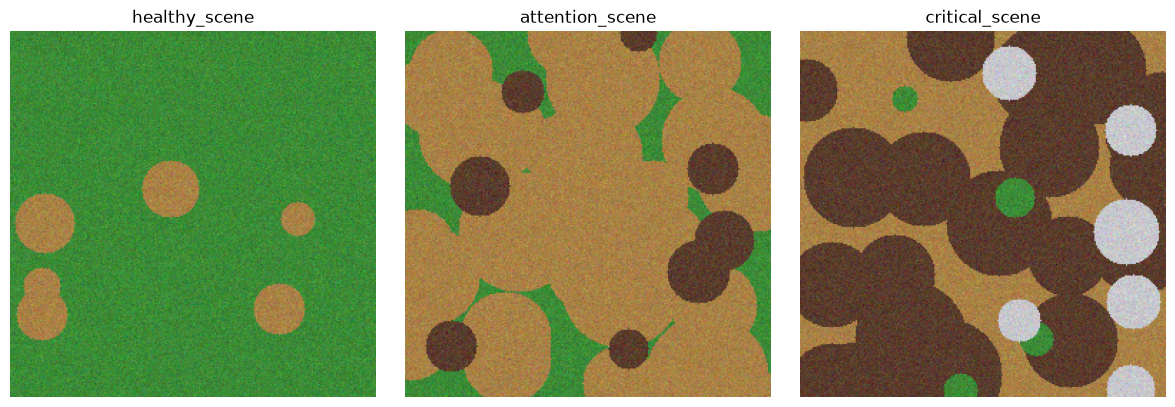

In [2]:
paths = generate_samples.generate(seed=42)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, p in zip(axes, paths):
    ax.imshow(Image.open(p))
    ax.set_title(p.stem)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Analyze each scene

The detector returns a risk class plus the index fractions (vegetation, dryness,
smoke) that justify the decision — fully interpretable.

In [3]:
import pandas as pd

rows = [analyze_scene(p).to_dict() for p in paths]
df = pd.DataFrame(rows)[[
    "image", "risk_label", "confidence",
    "vegetation_fraction", "dryness_fraction", "smoke_fraction",
]]
df

,image,risk_label,confidence,vegetation_fraction,dryness_fraction,smoke_fraction
0,healthy_scene.png,HEALTHY,0.929,0.956,0.021,0.000
1,attention_scene.png,ATTENTION,0.725,0.515,0.241,0.000
2,critical_scene.png,CRITICAL,0.655,0.267,0.381,0.066


## 3. Visualize the index masks

We recompute the three masks the classifier relies on and overlay them, so the
decision is transparent: green = vigorous vegetation, brown = dry/bare/burnt
soil, gray = smoke.

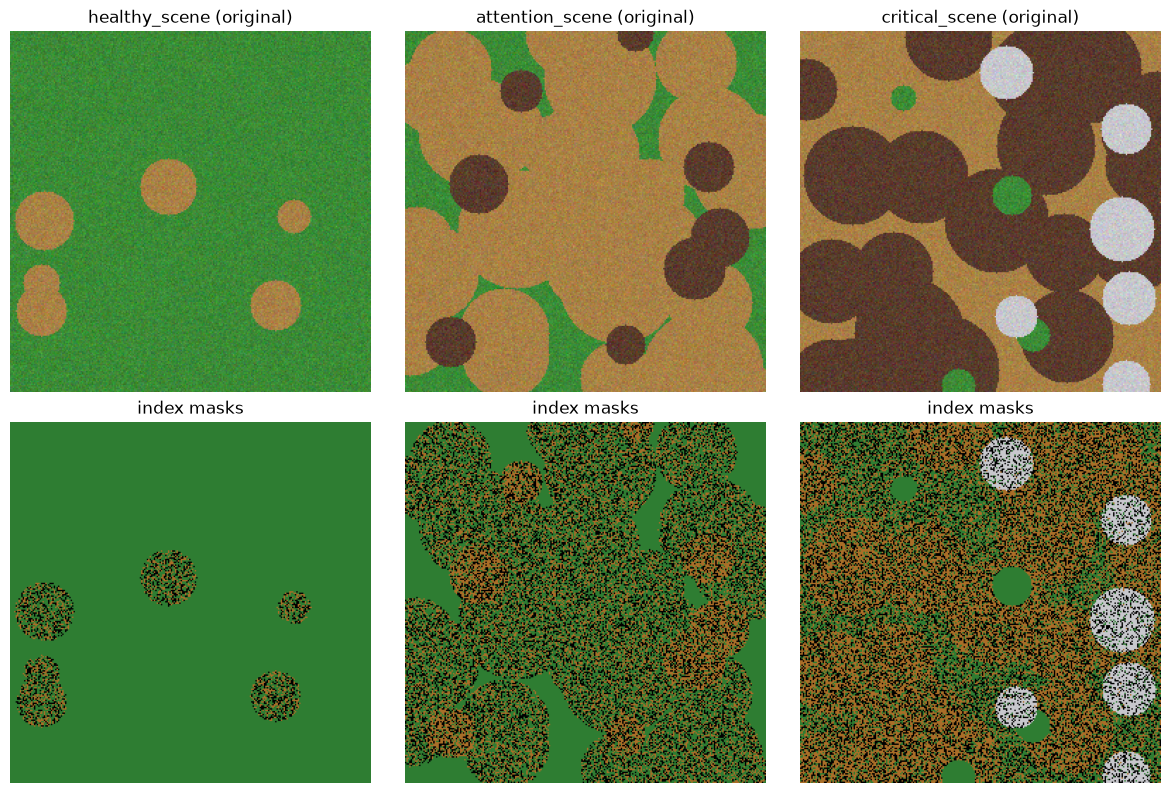

In [4]:
def masks(path):
    rgb = np.asarray(Image.open(path).convert("RGB")).astype(np.float64)
    total = rgb.sum(axis=2) + 1e-6
    r, g, b = rgb[..., 0] / total, rgb[..., 1] / total, rgb[..., 2] / total
    exg = 2 * g - r - b
    veg = exg > 0.06
    dry = (r > g) & (g > b) & (exg < 0.0)
    arr = rgb / 255.0
    bright = arr.mean(axis=2)
    sat = arr.max(axis=2) - arr.min(axis=2)
    smoke = (bright > 0.55) & (sat < 0.10)
    overlay = np.zeros_like(rgb)
    overlay[veg] = [46, 125, 50]
    overlay[dry] = [170, 110, 40]
    overlay[smoke] = [200, 200, 205]
    return overlay.astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for col, p in enumerate(paths):
    axes[0, col].imshow(Image.open(p))
    axes[0, col].set_title(f"{p.stem} (original)")
    axes[0, col].axis("off")
    axes[1, col].imshow(masks(p))
    axes[1, col].set_title("index masks")
    axes[1, col].axis("off")
plt.tight_layout()
plt.show()

## 4. (Optional) YOLO object detection

On **real** aerial imagery, the optional Ultralytics YOLO layer flags
infrastructure / field activity (vehicles, people, boats, aircraft). It degrades
gracefully: if `ultralytics` is not installed or weights can't be downloaded,
`detections` is simply empty and the scene analysis still works.

```python
from detector import analyze
result = analyze("samples/your_real_photo.jpg", run_yolo=True)
print(result.to_dict())
```

## Conclusion

- The vegetation-index analyzer cleanly separates the three risk classes using
  an interpretable RGB proxy for NDVI (ExG), fully offline and reproducible.
- Index fractions (vegetation / dryness / smoke) make every verdict auditable.
- The optional YOLO layer extends the platform to object detection on real
  aerial imagery without breaking the offline demo path.
- The same class mapping (`HEALTHY` / `ATTENTION` / `CRITICAL`) as the tabular
  model keeps the backend `/api/vision` and `/api/predict` responses consistent.

Run the CLI equivalent anytime with: `make samples && make analyze`.